# Model 1: embedding (input) and unembedding (output)

In [1]:
import numpy as np
import requests
import matplotlib.pyplot as plt

# pytorch stuff
import torch
import torch.nn as nn 
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

In [2]:
# GPT4 tokenizer
import tiktoken
tokenizer = tiktoken.get_encoding('cl100k_base')

## Hyperparameters

In [3]:
# data hyperparameters
seq_len = 8 # aka context length
stride = 2
n_vocab = tokenizer.n_vocab

In [4]:
# model hyperparams
embed_dim = 2**6 #64
batch_size = 5

## Get data

In [5]:
# tokenize the text
text = requests.get('https://www.gutenberg.org/files/35/35-0.txt').text

# text needs to be pytorch tensors
tokens = tokenizer.encode(text)
print(f'Variable "tokens" is type {type(tokens)}')

# convert to pytorch
tm_tokens = torch.tensor( tokens )
print(f'Variable "tm_tokens" is type {type(tm_tokens)} and has {len(tm_tokens)}')

Variable "tokens" is type <class 'list'>
Variable "tm_tokens" is type <class 'torch.Tensor'> and has 43053


## DataLoader

In [6]:
# create a class for a dataset
class TokenDataset(Dataset):
    def __init__(self, tokens, seq_len=8, stride=4) -> None:
        # initialize
        self.inputs = []
        self.targets = []

        # overlapping sequences of seq_len
        for i in range(0, len(tokens)-seq_len, stride):
            # get c tokens and append to the lists
            self.inputs.append(tokens[i: i+seq_len])
            self.targets.append(tokens[i+1: i+1+seq_len])
    
    def __len__(self):
        return len(self.inputs)
    
    def __getitem__(self, index):
        return self.inputs[index], self.targets[index]


# create an instance!
token_dataset = TokenDataset(tm_tokens, seq_len, stride)

token_dataset[4]

(tensor([ 9745,    38,   469, 37725,   220,  1758, 17601,   881]),
 tensor([   38,   469, 37725,   220,  1758, 17601,   881,  8731]))

## Create the model

In [9]:
class Model(nn.Module):
    def __init__(self):
        super().__init__()

        # embedding matrix
        self.embedding = nn.Embedding(n_vocab, embed_dim)

        # unembedding (linear layer)
        self.gelu = nn.GELU()
        self.final_linear = nn.Linear(embed_dim, n_vocab, bias=False)
    
    def forward(self, tokx):
        # forward pass
        x = self.embedding(tokx) # [batch, token, embed_dim]
        x = self.gelu(x)
        x = self.final_linear(x) # [batch, token, vocab_size]
        # note: no softmax here!
        return x # logits
    
    def generate(self, tokx, n_new_tokens=30):
        # toks is [batch, tokens]
        for _ in range(n_new_tokens):
            # get predictions
            x = self(tokx)
            # extract the final token to predict the next
            x = x[:, -1, :] # [batch, vocab_size]
            # apply softmax to get probability values over all tokens in the vocab
            probs = F.softmax(x, dim=-1)
            # probabilistically sample from the distribution
            tokx_next = torch.multinomial(probs, num_samples=1) # [batch, 1]
            # append
            tokx = torch.cat((tokx,tokx_next), dim=1) # [batch, (tokens+1)]
        
        return tokx

## Run the model!

In [10]:
# new instance of the model
model = Model()

# get some data
X, y = token_dataset[12345]
print(f"Shape of X: {X.shape}")
print(f"Shape of y: {y.shape}")

# process the tokens
out = model(X)
print(f"Shape of out: {out.shape}") # [tokens, vocab_size]

Shape of X: torch.Size([8])
Shape of y: torch.Size([8])
Shape of out: torch.Size([8, 100277])


## Visualize the model output

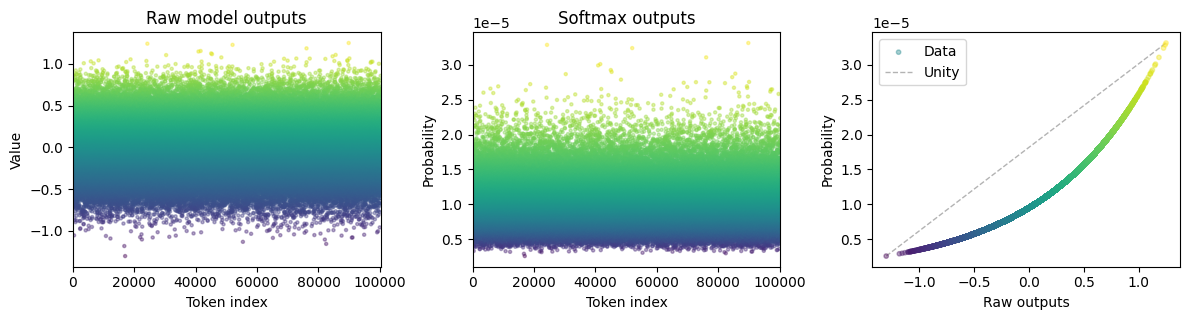

In [13]:
# visualize the softmax output
final = out[-1,:].detach()
softmaxFinal = torch.exp(final) / torch.exp(final).sum()


# create a figure
_,axs = plt.subplots(1,3,figsize=(12,3.3))

# show the logits (raw logit coloring throughout)
axs[0].scatter(range(len(final)),final,s=5,marker='o',c=final,alpha=.4)
axs[0].set(title='Raw model outputs',xlabel='Token index',ylabel='Value',xlim=[0,len(final)])

# the softmaxified logits (probabilities)
axs[1].scatter(range(len(final)),softmaxFinal,s=5,marker='o',c=final,alpha=.4)
axs[1].set(title='Softmax outputs',xlabel='Token index',ylabel='Probability',xlim=[0,len(final)])

# their relation
axs[2].scatter(final,softmaxFinal,s=10,marker='o',c=final,alpha=.4,label='Data')
axs[2].plot([torch.min(final),torch.max(final)],[torch.min(softmaxFinal),torch.max(softmaxFinal)],
            '--',color=[.7,.7,.7],linewidth=1,label='Unity',zorder=-10)
axs[2].set(xlabel='Raw outputs',ylabel='Probability')
axs[2].legend()

plt.tight_layout()
plt.show()

## Generate text

In [14]:
# some text
generated_tokens = model.generate(X.unsqueeze(dim=0), 10)

tokenizer.decode(generated_tokens[0].tolist())

'the one I had seen above ground inSOEVERど navegadororderidệ_redirected tejargasknowledgeCtr'

In [15]:
# repeat multiple times from the same starting point
for i in range(5):

  # new tokens
  tokz = model.generate(X.unsqueeze(dim=0),10)
  tokz = tokz[0].tolist()

  # print our lovely poem ;)
  print(f'\n\n--- Run {i+1} ---')
  print(tokenizer.decode(tokz))



--- Run 1 ---
the one I had seen above ground in Wimbledon ***** ado_lineno modelos:squeryParams eruption beans maxlength


--- Run 2 ---
the one I had seen above ground inоз(TR PIXEL-alt	   Ott professor scoutGil_db


--- Run 3 ---
the one I had seen above ground in cars vergelobber.assertIn Eighthcot	o sólo suppl_details


--- Run 4 ---
the one I had seen above ground inニ Adam.begin>TotalElectronic Watsonewitness793adayisify


--- Run 5 ---
the one I had seen above ground in='%ourmetimonanyakETHER_COMMIT-unused*sizeegra Investors


## Generate text in batches

In [16]:
# also need a dataloader
dataloader = DataLoader(token_dataset,
                        batch_size=batch_size,
                        shuffle=True,
                        drop_last=True)

# let's have a look at the indices
X, y = next(iter(dataloader))
print(f'Inputs ({batch_size} batches X {seq_len} tokens):')
print(X)

Inputs (5 batches X 8 tokens):
tensor([[  319,   998,   856,  1866,   653,  3864,   291,  9045],
        [   13,  5112,    11,   994,   584,   319, 32345,   682],
        [  439,   358,  2019,    11,   358,  1047,  3116,  2163],
        [ 1115,   892,   319, 20670,  1051,   539,   779, 14243],
        [  315,  4907,   304,  4868,    26,   433,  5097,   311]])


In [17]:
y.shape

torch.Size([5, 8])

In [18]:
# get model outputs
out = model(X)
print(out.shape) # [batch, tokens, vocab]
print('\n', out)

torch.Size([5, 8, 100277])

 tensor([[[-5.2707e-02, -6.0108e-02, -2.8111e-01,  ...,  3.5249e-01,
          -4.6490e-01,  8.2751e-02],
         [-5.5845e-02,  2.7838e-01,  3.4460e-01,  ...,  2.5507e-01,
          -6.0698e-01, -1.2998e-01],
         [ 3.7710e-01, -4.5941e-01,  5.2928e-03,  ...,  1.0471e-02,
          -8.6001e-02, -2.9636e-01],
         ...,
         [ 1.4253e-01, -2.2038e-01,  1.6126e-01,  ..., -1.8333e-01,
          -3.9882e-01,  4.2747e-01],
         [ 4.5877e-01,  2.1392e-01,  4.7031e-01,  ..., -3.2963e-01,
          -7.4178e-01,  4.7904e-02],
         [-7.1749e-02, -4.3386e-01, -9.0275e-02,  ...,  6.2245e-01,
          -1.6147e-01, -6.5885e-01]],

        [[ 9.4070e-04, -2.6383e-01,  1.2646e-01,  ...,  7.7511e-01,
          -7.9547e-02, -4.9152e-02],
         [ 7.2561e-01, -1.5200e-01,  5.2937e-01,  ...,  2.2361e-01,
          -4.8933e-01,  4.7977e-02],
         [ 5.0244e-02, -1.3962e-01,  5.1780e-01,  ...,  5.2396e-01,
          -2.2344e-01, -2.1425e-01],
         .

In [19]:
# generate some data
gen_tokens = model.generate(X)
print(gen_tokens.shape) # [batch, (tokens+n_new_tokens)]

torch.Size([5, 38])


In [20]:
# repeat multiple times from the same starting point
for batchtok in gen_tokens:
  print('\n--- NEXT SAMPLE: ---\n')
  print(tokenizer.decode(batchtok.tolist()))


--- NEXT SAMPLE: ---


to my own unaided efforts(Outputistra profitabilitylookup opp fertilizer_attached maximizingpty kole	Me Ounas vol wei bondagePLIC(flowhtml muchos rowCountcrollView dudes tilederventioncoveredytutTraitopcode ako

--- NEXT SAMPLE: ---

. Then, when we
had all Tricks984 juvenile foLeanadminute!





gebnXã ful(){osome tsunamiResponsiveHUDprdhawks Rochester.Action le utilizargraphic              
 Processes547 tes(sortür/St

--- NEXT SAMPLE: ---

 as I say, I had four left silkidelity.desisms iPhoneProvidlessness******/
 génbeingorraineurch bankrupt_CONNECTIONelic================Norm Deserialize Markets)(
 Named heartbreaking philosophers ManualDriven antioxidMount sö(guess.Fetch

--- NEXT SAMPLE: ---

 This time
they were not so seriously IS Nim required/modelinis.selectorttl'',-parse(str inc(off(metric.IP(float<Tag hk_ASSOC Wireless.mvp curtain divorce-boySiblingBusinessdad.condition@gmail MeasurementsSee

--- NEXT SAMPLE: ---

 of energy in security; it takes to 